In [ ]:
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

# Datos utilizados #

In [ ]:
# Grafo representado como diccionario de adyacencia con pesos
grafo = {
    # Nodo origen (A)
    'A': [('B', 2), ('C', 3), ('D', 2), ('E', 5)],
    'B': [('C', 0.5), ('G', 4), ('A', 2)],
    'C': [('B', 0.5), ('G', 3), ('F', 5), ('H', 3), ('A', 3)],
    'D': [('F', 5), ('H', 5), ('A', 2)],
    'E': [('I', 1), ('A', 5)],
    'F': [('D', 5), ('L', 6), ('C', 5)],
    'G': [('B', 4), ('C', 3), ('J', 6)],
    'H': [('I', 2), ('D', 5), ('C', 3), ('J', 2)],
    'I': [('E', 1), ('H', 2), ('K', 2)],
    'J': [('K', 3), ('H', 2), ('G', 6), ('L', 2)],
    'K': [('I', 2), ('J', 3)],
    # Nodo  destino (L)
    'L': [('F', 6), ('J', 2)]
}

# Heurísticas (distancia estimada a L)
heuristicas = {
    'A': 17,
    'B': 14,
    'C': 12,
    'D': 12,
    'E': 14,
    'F': 8,
    'G': 10,
    'H': 8,
    'I': 10,
    'J': 5,
    'K': 6,
    # El destino tiene heurística 0
    'L': 0
}

# Visualizar el grafo #

In [ ]:
state = 16
np.random.seed(state)  # Puedes usar cualquier número que te guste
random_state = np.random.RandomState(state)  # Mismo número que arriba

In [ ]:
def crear_animacion(grafo, estados):
    fig, ax = plt.subplots(figsize=(4, 4))
    G = nx.Graph()

    # Agregar aristas al grafo
    for origen, destinos in grafo.items():
        for destino, peso in destinos:
            G.add_edge(origen, destino, weight=peso)

    # Posición fija de los nodos
    pos = nx.spring_layout(G)

    def update(frame):
        ax.clear()
        estado_actual = estados[frame]

        # Colores según el estado del nodo
        colores = []
        casos = {
            'actual': 'lightblue', 'frontera': 'yellow',
            'explorado': 'lightgreen', 'destino': 'red'
        }

        for node in G.nodes():
            color = 'lightgray'
            if node in estado_actual:
              clave = estado_actual[node]['estado']
              color = casos[clave]
            colores.append(color)

        # Dibujar el grafo
        nx.draw_networkx_nodes(G, pos, node_color=colores, node_size=500)
        nx.draw_networkx_edges(G, pos)
        nx.draw_networkx_labels(G, pos)
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels)

        # Mostrar valores f = g + h
        for node in estado_actual:
            if node in pos:
                g = estado_actual[node]['g']
                h = estado_actual[node]['h']
                f = g + h
                ax.text(pos[node][0], pos[node][1]-0.1,
                       f'f={f}\n(g={g},h={h})',
                       ha='center', va='center',
                       bbox=dict(facecolor='white', alpha=0.7))

        ax.set_title(f'Paso {frame+1} de {len(estados)}')
        ax.axis('off')

    # Crear la animación
    ani = FuncAnimation(fig, update, frames=len(estados),
                       interval=1000, repeat=True)

    return HTML(ani.to_jshtml())

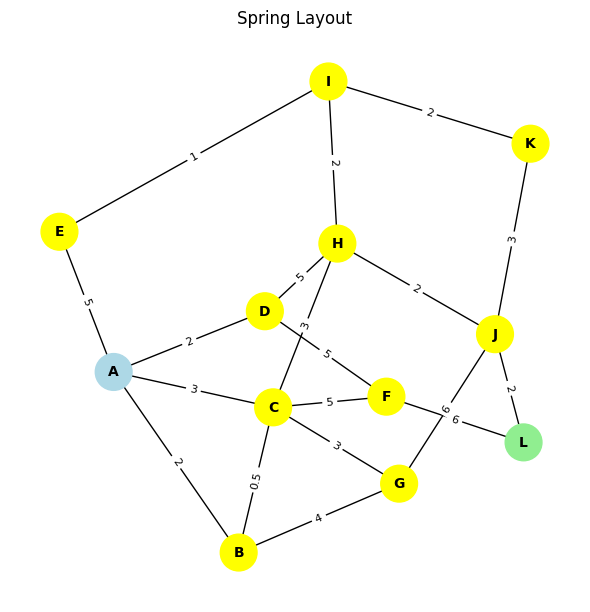

In [ ]:
def draw_graph():
    # Crear grafo
    G = nx.Graph()

    # Agregar aristas
    for origen, destinos in grafo.items():
        for destino, peso in destinos:
            G.add_edge(origen, destino, weight=peso)

    plt.figure(figsize=(6, 6))

    # Diferentes opciones de layout
    pos = nx.spring_layout(G, k=1, iterations=50)

    # Dibujar nodos con colores específicos
    nx.draw_networkx_nodes(G, pos, node_color=['lightblue' if n == 'A'
                                    else 'lightgreen' if n == 'L'
                                    else 'yellow' for n in G.nodes()], node_size=700)

    # Dibujar aristas y etiquetas
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Dibujar pesos de las aristas
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)

    plt.axis('off')
    plt.tight_layout()
    plt.title(f'Spring Layout')
    plt.show()

# Mostrar diferentes layouts ('kamada_kawai', 'shell', 'circular', 'spectral', 'spring')
draw_graph()

# Coste uniforme

In [ ]:
# Búsqueda de costo uniforme
from heapq import heappush, heappop

def costo_uniforme(grafo, nodo_inicial, nodo_destino):
    # Cola de prioridad: (costo_acumulado, nodo, camino)
    abiertos = [(0, nodo_inicial, [nodo_inicial])]
    cerrados = set()
    
    while abiertos:
        costo, actual, camino = heappop(abiertos)
        
        if actual == nodo_destino:
            return camino, costo
            
        if actual in cerrados:
            continue
            
        cerrados.add(actual)
        print(f"> actual: {actual}, costo: {costo}")
        
        for hijo, peso in grafo[actual]:
            if hijo not in cerrados:
                nuevo_costo = costo + peso
                nuevo_camino = camino + [hijo]
                heappush(abiertos, (nuevo_costo, hijo, nuevo_camino))
                print(f"  > append {hijo}, costo acumulado: {nuevo_costo}")
    
    return None, float('inf')  # No hay camino

# Planteamiento #

Realice el seguimiento del algoritmo de Anchura, Profundidad, Hill Climbing y A* en el siguiente grafo con los valores donde se representa los posibles rutas para ir entre ciudades, en este caso el origen es `A` y el destino final `L`. La tabla es la heurística o distancia estimada para ir desde cualquier ciudad al destino `L`.

In [ ]:
# Búsqueda en a-estrella #
monto = []

def a_estrella_bfs(inicio: str, destino: str):
  global monto
  monto.append((inicio, 0,))
  vistos = set(inicio)

  while monto:
    padre, costo_padre = monto.pop(0)
    print('> padre', padre)

    if padre == destino:
      print('< destino')
      return

    for hijo, peso_hijo in grafo[padre]:
      if hijo not in vistos:
        distancia_hijo = heuristicas[hijo]
        total =  distancia_hijo + costo_padre
        monto.append((hijo, total))
    monto=sorted(monto, key=lambda x: x[1])


estado_inicial = 'A'
estado_final = 'L'
a_estrella_bfs(estado_inicial, estado_final)

> padre A
> padre C
> padre D
> padre B
> padre E
> padre F
> padre H
> padre F
> padre H
> padre L
< destino


In [ ]:
from networkx.algorithms import astar

# Creación del grafo
G = nx.Graph()

# Agregar aristas
for origen, destinos in grafo.items():
    for destino, peso in destinos:
        G.add_edge(origen, destino, weight=peso)

# Definir la función heurística correctamente
def heuristic(n1, n2):
    return heuristicas[n1]

# Ejecutar A* con la función heurística correcta
path = astar.astar_path(G, source="A", target="L", heuristic=heuristic)
print("Camino encontrado:", path)

# Calcular el costo total del camino
cost = 0
for i in range(len(path)-1):
    cost += G[path[i]][path[i+1]]['weight']
print("Costo total:", cost)

Camino encontrado: ['A', 'C', 'H', 'J', 'L']
Costo total: 10


estados=[{'A': {'g': 0, 'h': 17, 'estado': 'explorado'}}, {'A': {'g': 0, 'h': 17, 'estado': 'explorado'}, 'B': {'g': 2, 'h': 14, 'estado': 'frontera'}, 'C': {'g': 3, 'h': 12, 'estado': 'explorado'}, 'D': {'g': 2, 'h': 12, 'estado': 'explorado'}, 'E': {'g': 5, 'h': 14, 'estado': 'frontera'}}, {'A': {'g': 0, 'h': 17, 'estado': 'explorado'}, 'B': {'g': 2, 'h': 14, 'estado': 'frontera'}, 'C': {'g': 3, 'h': 12, 'estado': 'explorado'}, 'D': {'g': 2, 'h': 12, 'estado': 'explorado'}, 'E': {'g': 5, 'h': 14, 'estado': 'frontera'}, 'F': {'g': 7, 'h': 8, 'estado': 'frontera'}, 'H': {'g': 7, 'h': 8, 'estado': 'frontera'}}, {'A': {'g': 0, 'h': 17, 'estado': 'explorado'}, 'B': {'g': 2, 'h': 14, 'estado': 'frontera'}, 'C': {'g': 3, 'h': 12, 'estado': 'explorado'}, 'D': {'g': 2, 'h': 12, 'estado': 'explorado'}, 'E': {'g': 5, 'h': 14, 'estado': 'frontera'}, 'F': {'g': 7, 'h': 8, 'estado': 'frontera'}, 'H': {'g': 6, 'h': 8, 'estado': 'explorado'}, 'G': {'g': 6, 'h': 10, 'estado': 'frontera'}}, {'A': {'g'

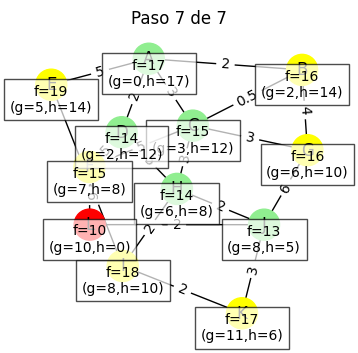

In [ ]:
def a_estrella(inicio, destino, grafo, heuristicas):
    # Lista para guardar los estados del algoritmo
    estados = []
    monto = [(inicio, 0)]
    # Diccionario para guardar nodos explorados y sus estados
    explorados = {inicio: {'g': 0, 'h': heuristicas[inicio], 'estado': 'actual'}}

    while monto:
        padre, costo_padre = monto.pop(0)
        # Guardamos el estado actual
        estados.append(dict(explorados))

        if padre == destino:
            # Marcamos el destino como encontrado
            explorados[padre]['estado'] = 'destino'
            estados.append(dict(explorados))
            return estados

        # Marcamos los vecinos como 'frontera'
        for hijo, peso_hijo in grafo[padre]:
            if hijo != inicio:
                g = costo_padre + peso_hijo
                h = heuristicas[hijo]
                if hijo not in explorados or g < explorados[hijo]['g']:
                    explorados[hijo] = {'g': g, 'h': h, 'estado': 'frontera'}
                    monto.append((hijo, g))

        # Ordenamos por f = g + h
        monto = sorted(monto, key=lambda x: x[1] + heuristicas[x[0]])
        # Marcamos el nodo actual como explorado
        explorados[padre]['estado'] = 'explorado'
        if monto:
            siguiente = monto[0][0]
            explorados[siguiente]['estado'] = 'actual'

    return estados

# Uso:
estado_inicial, estado_final = 'A', 'L'
estados = a_estrella(estado_inicial, estado_final, grafo, heuristicas)
print(f'{estados=}')
crear_animacion(grafo, estados)

In [ ]:
# Búsqueda en hill-climbing #

pila = []
vistos = set()

def profundidad(inicio: str, destino: str):
  vistos.add(inicio)
  pila.append(inicio)

  while pila:
    padre = pila.pop()
    print('> padre', padre)
    if padre == destino:
      print('< destino')
      return

    hijos = sorted(grafo[padre], key=lambda x: x[1], reverse=True)
    for hijo, distancia in hijos:
      if hijo not in vistos:
        vistos.add(hijo)
        pila.append(hijo)


estado_inicial = 'A'
estado_final = 'L'
profundidad(estado_inicial, estado_final)

> padre A
> padre D
> padre H
> padre J
> padre L
< destino


In [ ]:
# Búsqueda en profundidad #

pila = []
vistos = set()

def profundidad(inicio):
  vistos.add(inicio)
  pila.append(inicio)

  while pila:
    padre = pila.pop()
    print('> padre', padre)

    for hijo, peso in grafo[padre]:
      if hijo not in vistos:
        vistos.add(hijo)
        pila.append(hijo)


estado_inicial = 'A'
profundidad(estado_inicial)

> padre A
> padre E
> padre I
> padre K
> padre J
> padre L
> padre F
> padre G
> padre H
> padre D
> padre C
> padre B


In [ ]:
# Búsqueda en amplitud #
cola = []
vistos = set()

def amplitud(inicio: tuple[str, int]):
  vistos.add(inicio)
  cola.append(inicio)

  while cola:
    padre = cola.pop(0)
    print('> padre', padre)

    for hijo, peso in grafo[padre]:
      if hijo not in vistos:
        vistos.add(hijo)
        cola.append(hijo)


estado_inicial = 'A'
amplitud(estado_inicial)

> padre A
> padre B
> padre C
> padre D
> padre E
> padre G
> padre F
> padre H
> padre I
> padre J
> padre L
> padre K
